# Exercise 30.1a solution


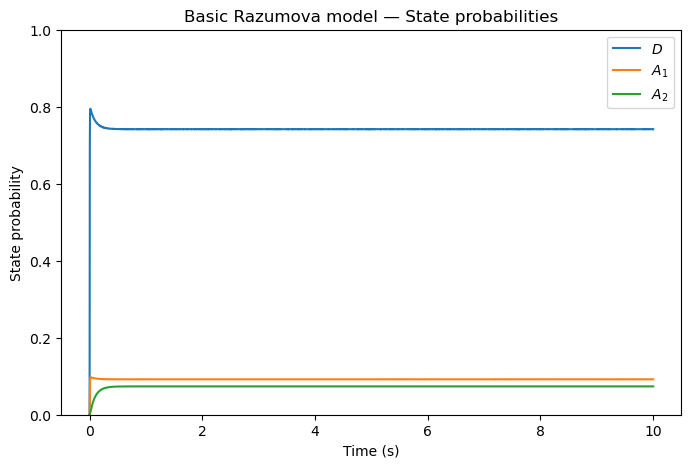

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Initial conditions
D_0 = 0.0
A1_0 = 0.0
A2_0 = 0.0

# Rate constants
R_T = 1
k_on = 400
k_off = 50
f = 50
f_prime = 400
h = 8
h_prime = 6
g = 4


def rhs(t, y):
    """Right-hand side of the basic Razumova model."""
    D, A_1, A_2 = y
    R_off = R_T - D - A_1 - A_2

    dD_dt = k_on * R_off + f_prime * A_1 + g * A_2 - (k_off + f) * D
    dA1_dt = f * D + h_prime * A_2 - (f_prime + h) * A_1
    dA2_dt = h * A_1 - (h_prime + g) * A_2

    return [dD_dt, dA1_dt, dA2_dt]


# Solve
t_span = (0, 10)
t_eval = np.linspace(*t_span, 5000)
sol = solve_ivp(rhs, t_span, [D_0, A1_0, A2_0], t_eval=t_eval, method="RK45")

D = sol.y[0]
A_1 = sol.y[1]
A_2 = sol.y[2]
time = sol.t

plt.figure(figsize=(8, 5))
plt.plot(time, D, label=r"$D$")
plt.plot(time, A_1, label=r"$A_1$")
plt.plot(time, A_2, label=r"$A_2$")
plt.xlabel("Time (s)")
plt.ylabel("State probability")
plt.title("Basic Razumova model — State probabilities")
plt.ylim(0, 1)
plt.legend()
plt.show()